In [1]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 6, 9, 12, 15, 19, 22, 25, 27, 31, 35])

nb_name = "03_normalization_batch_correction.ipynb"

_compare_version(nb_name)

# 03 - Normalization and Batch effect correction
<hr style="border:2px solid black"> </hr>

## 1 - Description

Similar to quality control and filtering this step is aimed to prepare the data to facilitate better results in the following analysis steps. However, with normalization and batch effect correction the aim is to refine the data points in a way that

1. comparability between e.g. samples is enhanced
2. the influence of outliers is mitigated
3. variances introduced by technical or otherwise unwanted sources are omitted from the dataset.

Since this reduces the overall noise, the embedding and clustering steps in particular benefit from these adjustments.

___________

## 2 - Setup

In [2]:
import pandas as pd
import scanpy as sc
from pathlib import Path

import sctoolbox.utils as utils
import sctoolbox.tools as tools
import sctoolbox.plotting as pl
from sctoolbox import settings

settings.settings_from_config("config.yaml", key="03")

# Set additional options for figures
sc.set_figure_params(vector_friendly=True, dpi_save=600, scanpy=False)

with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Created directory: ../figures/03_batch_correction/
Created directory: ../report/03_batch_correction/


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,sctoolbox,NA
2,pandas,2.3.3
3,numpy,2.3.5
4,anndata,0.12.6
5,scanpy,1.11.5


___________

## 3 - Load anndata
Loads the anndata.h5ad from the last notebook and provides a basic overview.

In [3]:
adata = utils.adata.load_h5ad("anndata_2.h5ad")

with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)
    display(adata.var)

[INFO] The adata object was loaded from: ../adatas/anndata_2.h5ad


AnnData object with n_obs × n_vars = 3102 × 19031
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes'
    var: 'gene_id', 'is_mito', 'is_ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet', 'sctoolbox'

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes
AAACCTGAGCTTATCG-1,16,GSM5402439_scRNAseq_Sox10_Cre_bact_BtR_60dpf_r...,GSM5402439,60dpf,rep_1,Mesenchyme,6047.0,8.707483,118.0,4.779123,1.951381,3394.0,8.130059,56.127007,0.043802,False,Male,1087,6.992096
AAACCTGAGGGATCTG-1,6,GSM5402439_scRNAseq_Sox10_Cre_bact_BtR_60dpf_r...,GSM5402439,60dpf,rep_1,Mesenchyme,858.0,6.755769,8.0,2.197225,0.932401,280.0,5.638355,32.634033,0.087087,False,Male,370,5.916202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCCATTAGCCA-2,3,GSM5402440_scRNAseq_Sox10_Cre_bact_BtR_60dpf_r...,GSM5402440,60dpf,rep_2,Mesenchyme,1635.0,7.400010,18.0,2.944439,1.100917,451.0,6.113682,27.584097,0.033186,False,Male,539,6.291569
TTTGGTTAGCAATATG-2,4,GSM5402440_scRNAseq_Sox10_Cre_bact_BtR_60dpf_r...,GSM5402440,60dpf,rep_2,Mesenchyme,2172.0,7.683864,20.0,3.044523,0.920810,768.0,6.645091,35.359116,0.170909,False,Male,649,6.476972


,gene_id,is_mito,is_ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
gene_symbol,,,,,,,,,
ptpn12,ENSDARG00000102141,False,False,3,0.000967,0.000967,99.903288,3.0,1.386294
phtf2-1,ENSDARG00000114503,False,False,2,0.000645,0.000645,99.935525,2.0,1.098612
...,...,...,...,...,...,...,...,...,...
TagBFP,TagBFP,False,False,90,0.103482,0.098470,97.098646,321.0,5.774551
DsRedExpress,DsRedExpress,False,False,2162,4.319794,1.671435,30.303030,13400.0,9.503084


___________

## 4 - General input
<hr style="border:2px solid black"> </hr>

### 4.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| species | The species of your data | `human`, `mouse`, `zebrafish`, `rat` |
| groupby | The name of a column in `adata.obs` to **plot** cell cycle phase cell counts per group | e.g. `sample` or `condition` column. If None, the counts for each phase in the whole dataset will be plotted |
| threads | the number of cores to use for multiprocessing | Default 4 |
| batch_column | For **batch correction**: A column in `adata.obs` (see table above) containing batch information | e.g. `batch` |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [4]:
species = "zebrafish"

groupby = 'sample'

settings.threads = 4

batch_column = "batch"

---------

In [5]:
# Ensure that the batch column is of type category
adata.obs[batch_column] = adata.obs[batch_column].astype(str).astype("category")

---------

## 5 - Plot highly expressed genes
<hr style="border:2px solid black"> </hr>

Show the top expressing genes to decide whether they should be included during the normalization (they are not removed from the dataset just excluded during normalization).

[INFO] Saving figure to ../figures/03_batch_correction/highly_expressed.pdf


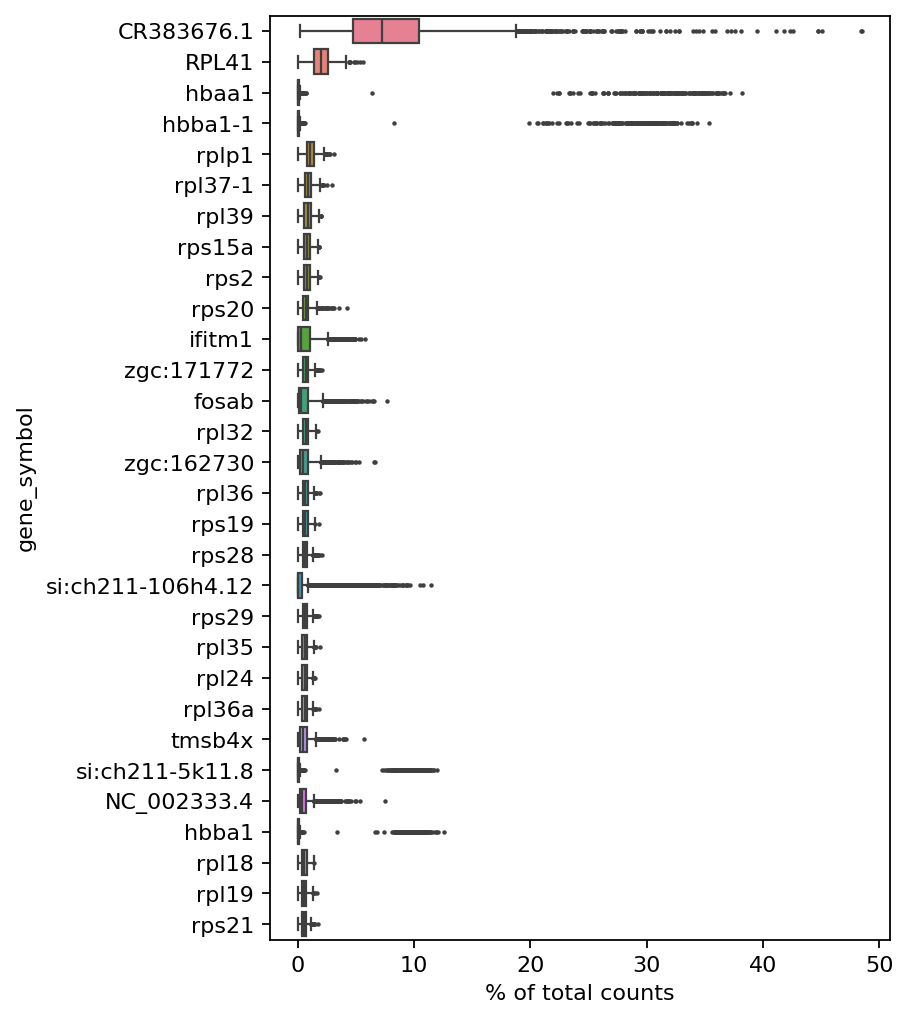

In [6]:
sc.pl.highest_expr_genes(adata, show=False)
pl.general._save_figure("highly_expressed.pdf")

### 5.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| exclude_highly_expressed | Choose if highly expressed genes should be excluded | `True` or `False` |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [7]:
exclude_highly_expressed = False

-------------

## 6 - Normalization
<hr style="border:2px solid black"> </hr>

This section performs the normalization followed by a dimension reduction. The counts for each cell are normalized so that all cells have the same number of counts after normalization. This removes imbalances due to sampling effects or sequencing depth to make the cells comparable.

To normalize the data we use a combination of the scanpy functions **sc.pp.normalize_total()** and **sc.pp.log1p()**. Hereby we aim to remove variability introduced by the sequencing depth by **sc.pp.normalize_total()**, which is basically a scaling resulting in values between 0 and 1. The function **sc.pp.log1p()** removes outliers by applying $f(x)=log(x+1)$ to the data.

**DOI: https://doi.org/10.1038/s41576-023-00586-w**

In [8]:
adata = tools.norm_correct.normalize_adata(adata, method="total", target_sum=None, exclude_highly_expressed=exclude_highly_expressed)

[INFO] Performing total normalization and PCA...


----------

## 7 - Predict Cell Cycle
Predict the division phase of each cell.

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Saving figure to ../figures/03_batch_correction/cell_distribution_phase_barplot.pdf


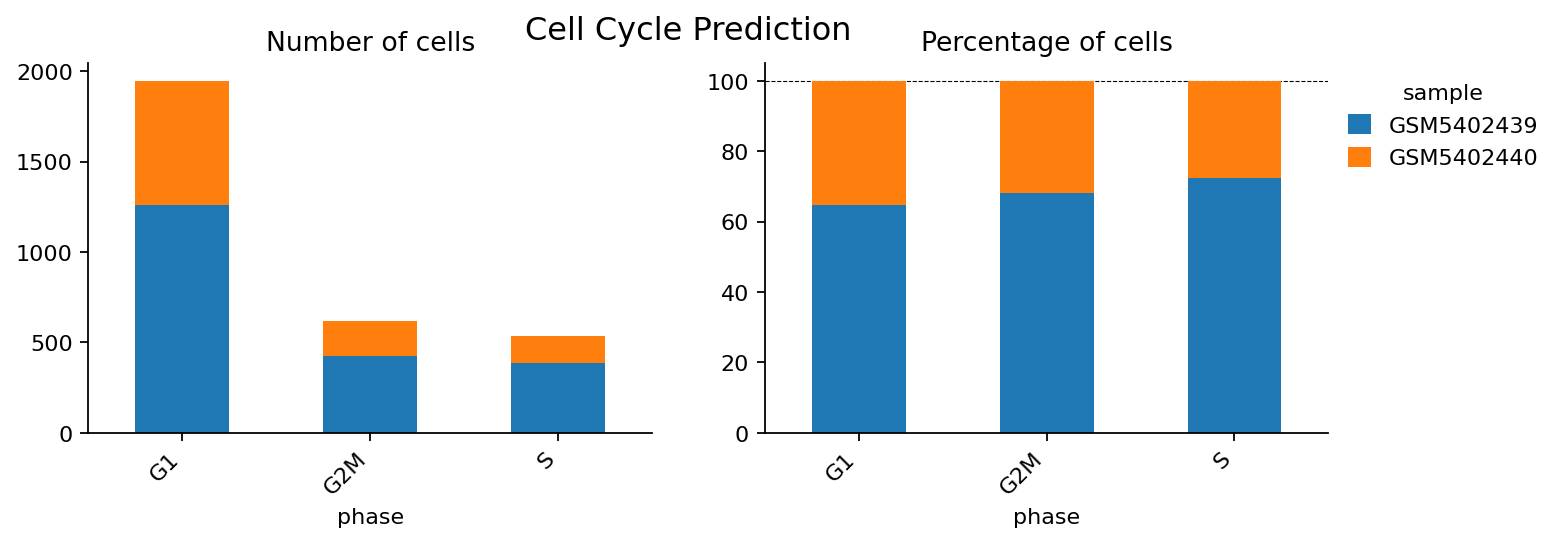

In [9]:
tools.qc_filter.predict_cell_cycle(adata, species=species, s_genes=None, g2m_genes=None, inplace=True,
                                   groupby=groupby, gene_column=None,
                                   save="cell_distribution_phase_barplot.pdf",
                                   report="01_cell_cycle_prediction.png")

-----------

## 8 - Find highly variable genes
<hr style="border:2px solid black"> </hr>

Identify genes that rapidly change expression levels between cells. These genes are considered to be highly informative about the underlying biological structure.

### 8.1 - Parameter Overview

Try to find the optimal parameter combination using the boundaries below

| Parameter | Description | Options |
|-----------|-------------|---------|
| min_limit | Minimum amount of expected variable genes | Default 1000 |
| max_limit | Maximum amount of expected variable genes | Default 5000 |
| min_disp | The minimum allowed spread the distribution of a gene can have | Default 0.5 |
| max_disp | The maximum allowed spread the distribution of a gene can have | Default `inf` |
| min_mean | Minimum allowed mean gene expression | Default 0.0125 |
| max_mean | Maximum allowed mean gene expression | Default 3 |

For more information see:

https://loosolab.pages.gwdg.de/software/sc_framework/API/tools.html#sctoolbox.tools.highly_variable.annot_HVG

https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html#scanpy-pp-highly-variable-genes

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [10]:
min_limit = 1000
max_limit = 5000 
min_disp = 0.5
max_disp = float('inf')
min_mean = 0.0125
max_mean = 3

[INFO] Annotating highy variable genes (HVG)
[INFO] Saving figure to ../figures/03_batch_correction/highly_variable.pdf
[INFO] Total HVG=1587


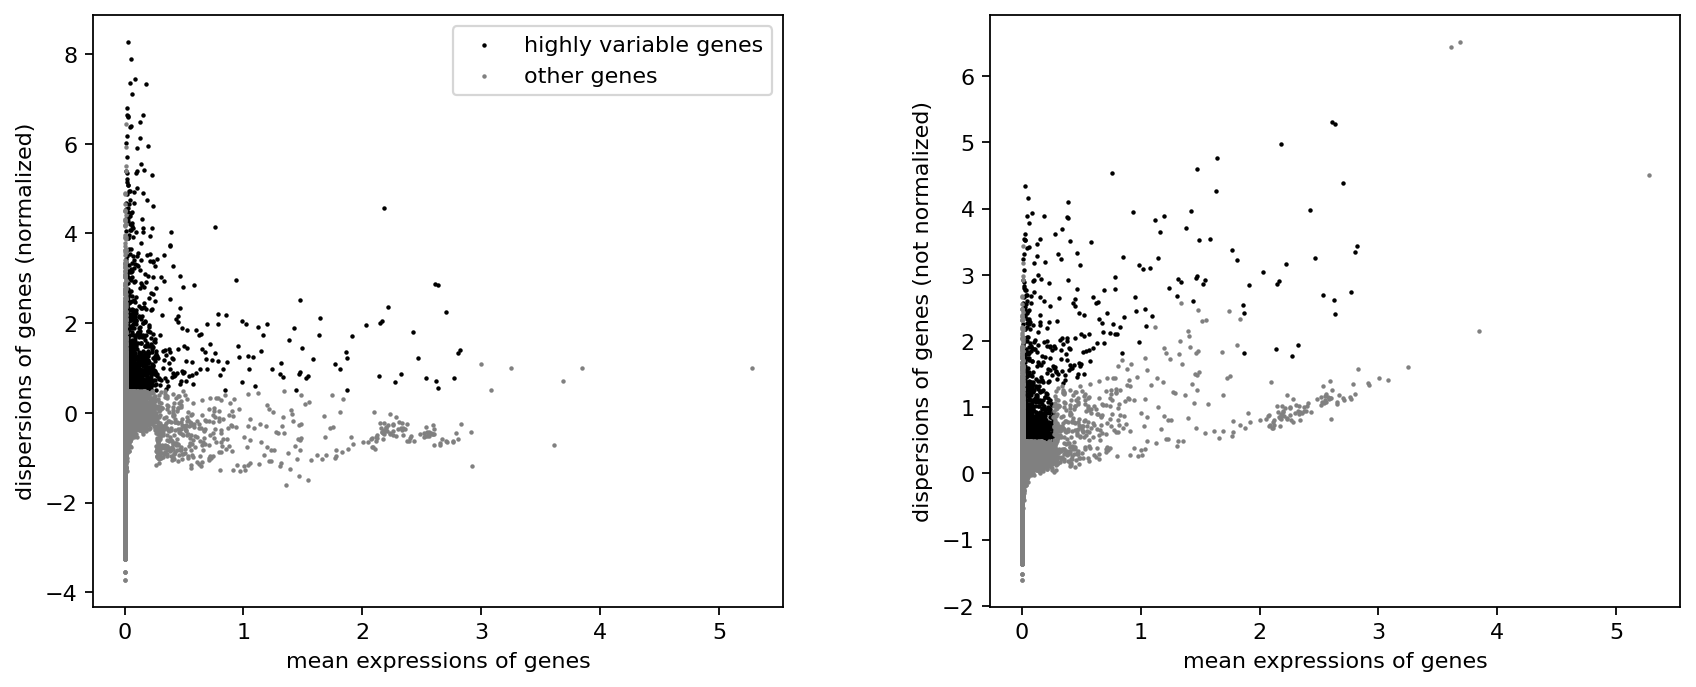

In [11]:
tools.highly_variable.annot_HVG(
    adata, 
    hvg_range=(min_limit, max_limit),
    min_disp=min_disp,
    max_disp=max_disp,
    min_mean=min_mean,
    max_mean=max_mean,
    save="highly_variable.pdf"
)

In [12]:
# Number of variable genes selected
adata.var["highly_variable"].sum()

np.int64(1587)

---------

## 9 - PCA and neighbors for uncorrected data
<hr style="border:2px solid black"> </hr>

Another important property of our data is its high dimensionality. However, this complexity hinders in-depth analysis e.g. the identification of cell states. Thus, dimension reduction algorithms are applied to reduce complexity while simultaneously retaining patterns, a crucial step to enable embedding and clustering. In other words, noise is reduced by removing low variance components as well as components explaining technical or otherwise unwanted factors (e.g. number of active genes, cell cycle, etc.) which also has the benefit of reducing the computational demand.

**DOI: [10.1038/nmeth.4346](https://doi.org/10.1038/nmeth.4346)**  

The following heatmaps and barplots are intended to identify potentially unwanted PCs by showing the PCs in combination with available observations (cell-related metrics) and variables (gene-related metrics). In general, **selected PCs should avoid correlations with metrics**, but the importance of metrics and the stringency of thresholds depends on the experiment and the underlying questions, and therefore requires careful consideration by the analyst.

In [13]:
n_pcs = 50  # The number of PCs to compute

In [14]:
default_pca_color = [k for k in adata.uns["sctoolbox"]["report"]["qc"]["obs"]["threshold"].keys() if k not in ["before", "after"]] + ["phase", batch_column]
default_pca_color

['log1p_total_counts',
 'n_genes',
 'pct_counts_is_mito',
 'pct_counts_is_ribo',
 'phase',
 'batch']

In [15]:
tools.dim_reduction.compute_PCA(adata, svd_solver='arpack', mask_var="highly_variable", n_comps=n_pcs, inplace=True, report=True)

[INFO] Computing PCA


### 9.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| n_pcs_heatmap | number of PCs shown within the heatmap | Default 15 |
| pca_color | columns in `adata.obs`or `adata.var` to be shown in the following PCA | list of **column names** (e.g. `[obs_column1, obs_column2, var_column2]`) or **leave empty** to use the list above |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [16]:
n_pcs_heatmap = 30

pca_color = []

___

[INFO] Saving figure to ../figures/03_batch_correction/PCA_embedding.pdf


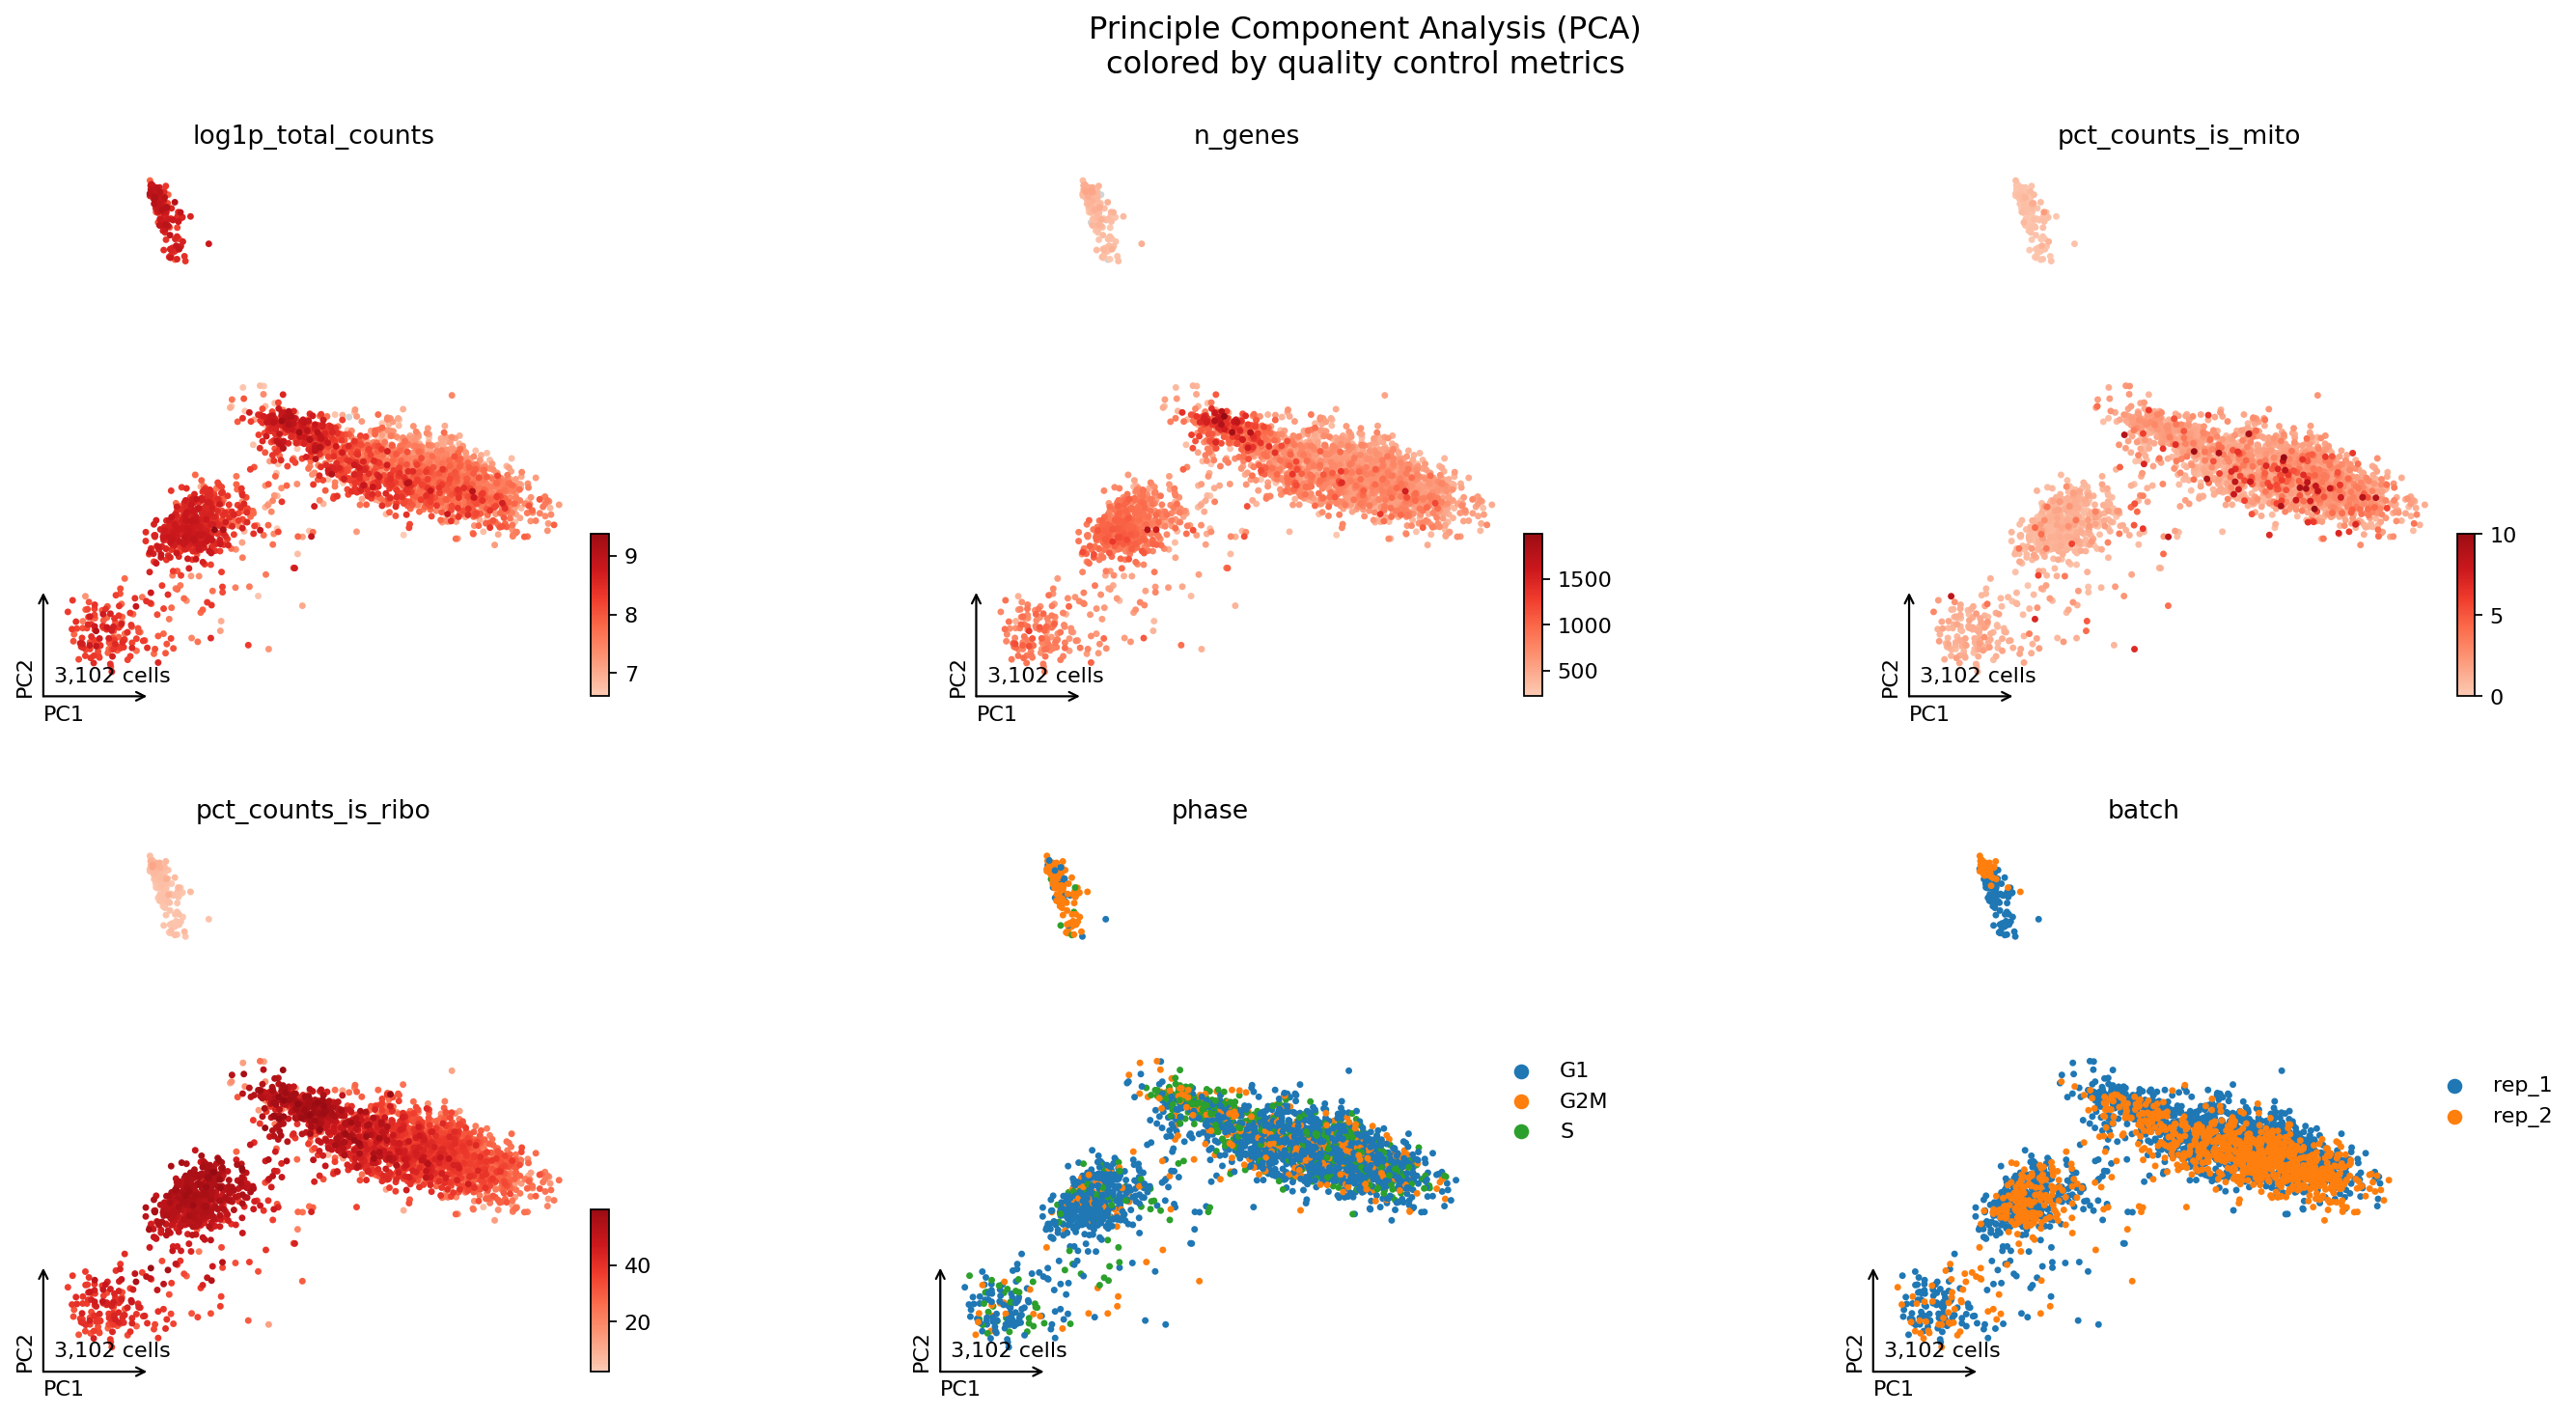

In [17]:
# Plot QC variables on the PCA embedding to show potential correlations
_ = pl.embedding.plot_embedding(
    adata,
    method='pca',
    color=pca_color if pca_color else default_pca_color,
    ncols=3,
    suptitle="Principle Component Analysis (PCA)\ncolored by quality control metrics",
    report="02_PCA_correlation_2D.png",
    save="PCA_embedding.pdf"
)

[INFO] Saving figure to ../figures/03_batch_correction/PCA_correlation_obs.pdf


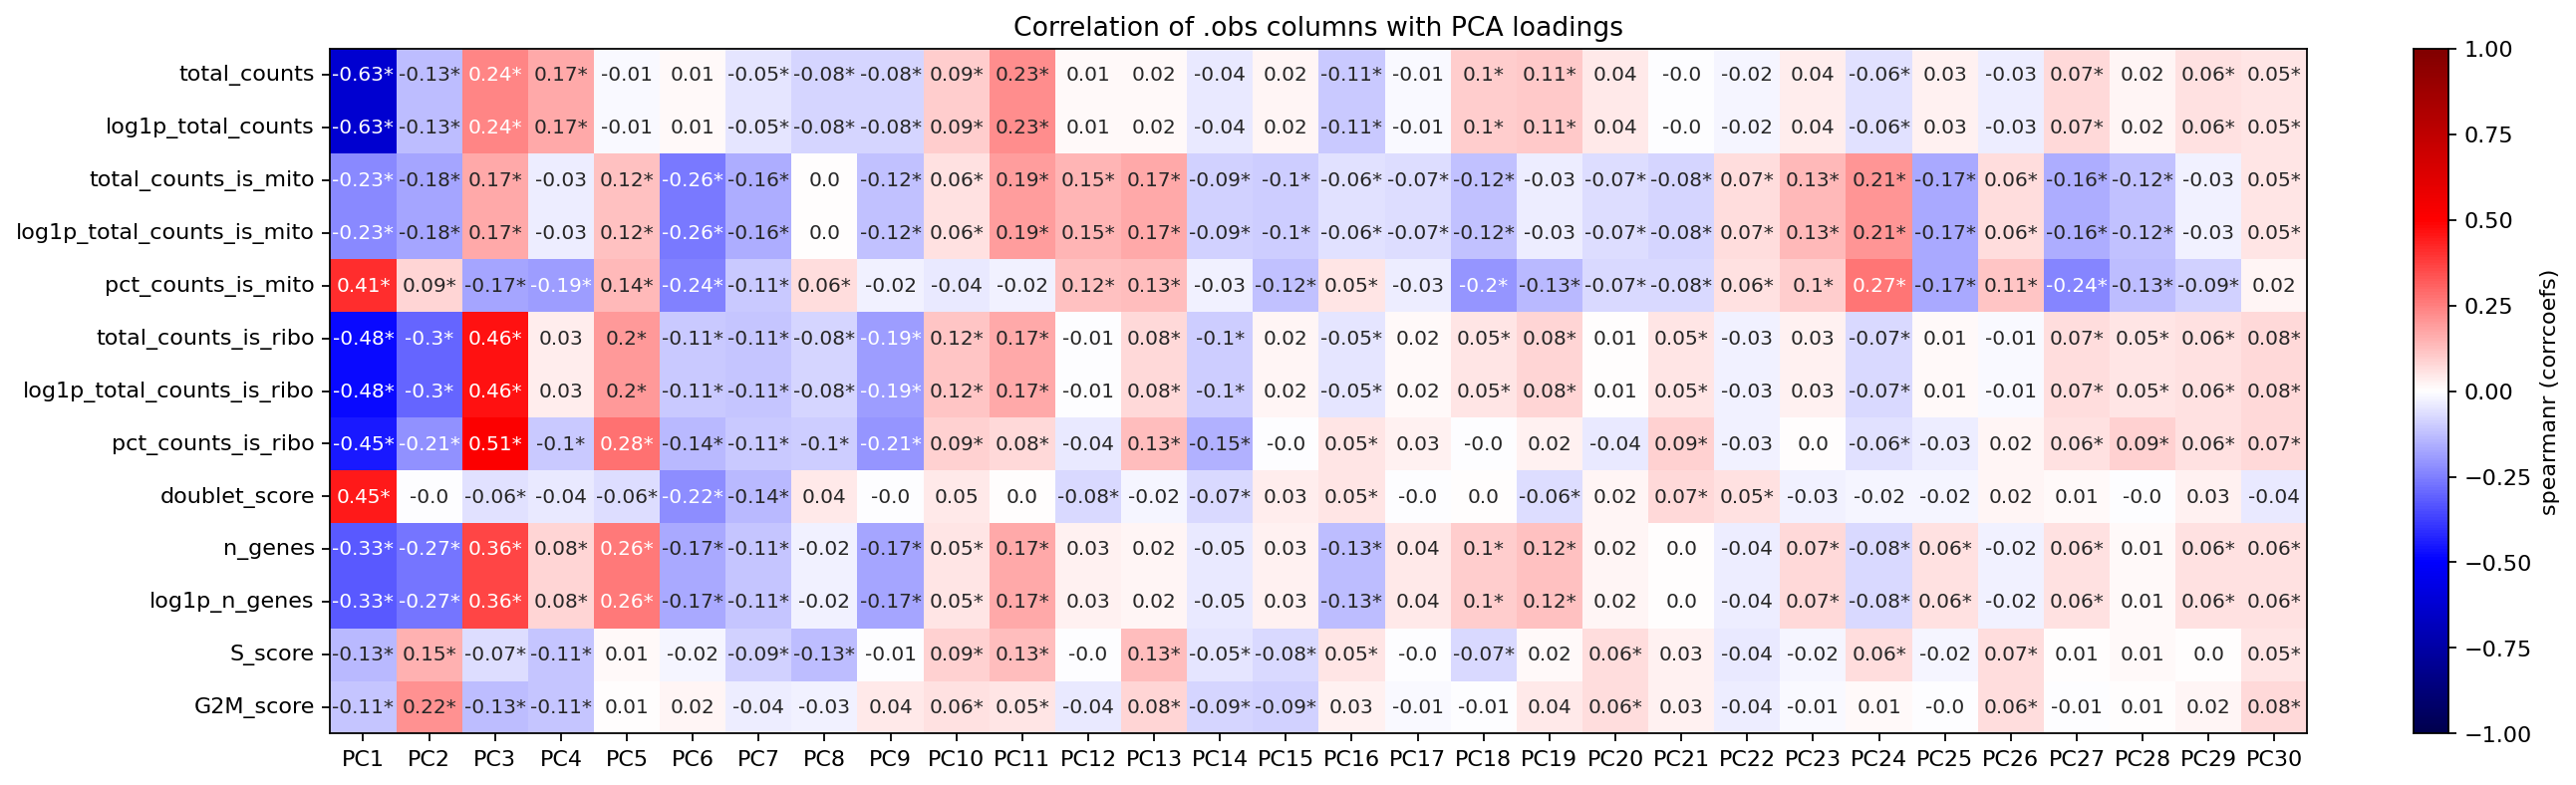

In [18]:
# PCA correlations with obs variables 
_ = pl.embedding.plot_pca_correlation(
    adata,
    n_components=n_pcs_heatmap,
    which="obs",
    title="Correlation of .obs columns with PCA loadings",
    save="PCA_correlation_obs.pdf"
)

[INFO] Saving figure to ../figures/03_batch_correction/PCA_correlation_var.pdf


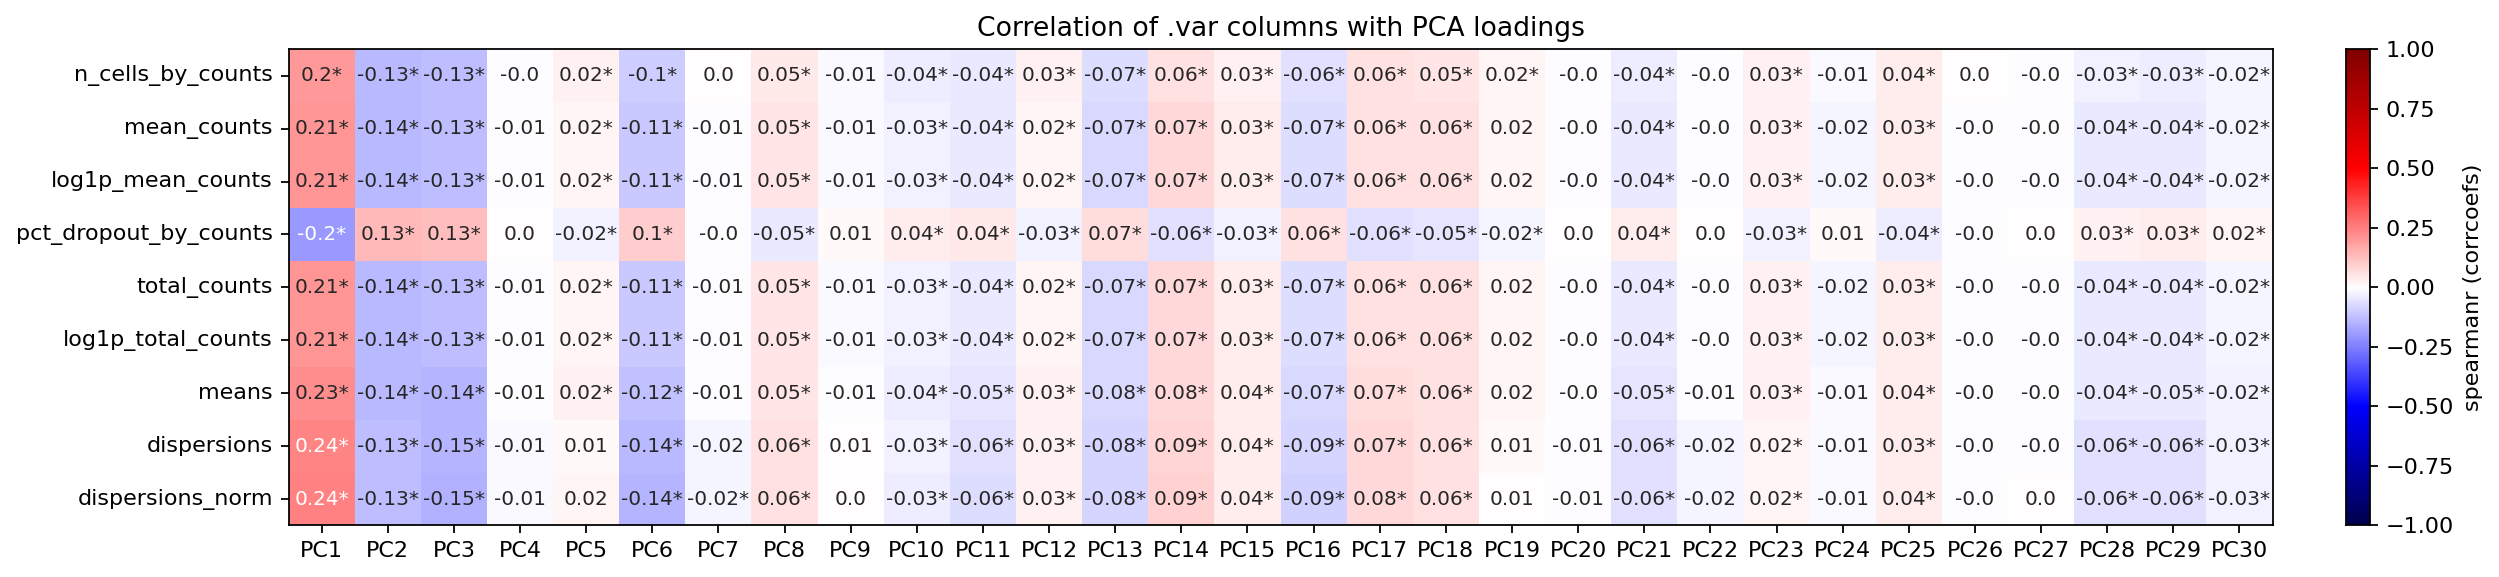

In [19]:
# PCA correlations with var variables
_ = pl.embedding.plot_pca_correlation(
    adata,
    n_components=n_pcs_heatmap,
    which="var",
    title="Correlation of .var columns with PCA loadings",
    save="PCA_correlation_var.pdf"
)

------------

### 9.2 - Choose a subset of PCs (optional)
<hr style="border:1px solid black"> </hr>

In case the above plots showed undesired correlation this section can be used to subset the PCs. The proposed PC subset is displayed as a plot with darker bars representing the selected PCs. Based on the selected `filter_methods`, a vertical and horizontal threshold line is displayed. PCs are filtered if they are below the horizontal threshold (`corr_thresh`) or if they are to the right of the vertical threshold line (`perc_thresh`).

#### 9.2.1 - Parameter Overview

| Parameter | Description | Options |
|:---:|:---|:---|
| subset_pcs | Whether the PCs should be filtered. | `True` or `False` |
| corr_thresh | Highest absolute correlation that is allowed. Will take the maximum correlation for each PC as shown in the heatmap above. PCs with an absolut correlation above this will be filtered | Expects a value between `0-1`. |
| perc_thresh | Top percentile of PCs that should be kept. | A value between `0-100`%. |
| filter_methods | The PCs will be filtered based on the given methods. E.g. for "variance" and "correlation" PCs are filtered on values from both methods and the intersection is used as the final subset. | Any combination of `["variance", "cumulative variance", "correlation"]` |
| basis | Compute correlation based on observations (cells) or variables (genes). | Either `obs` for cells or `var` for genes. |
|ignore_cols| List of column names to ignore for correlation | `None` or a list of column names|

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [20]:
subset_pcs = False

corr_thresh = 0.6
perc_thresh = 100
filter_methods = ['variance', 'correlation']
basis = 'obs'
ignore_cols = []

___

[INFO] Saving figure to ../figures/03_batch_correction/PCA_variance_proposed_selection.pdf


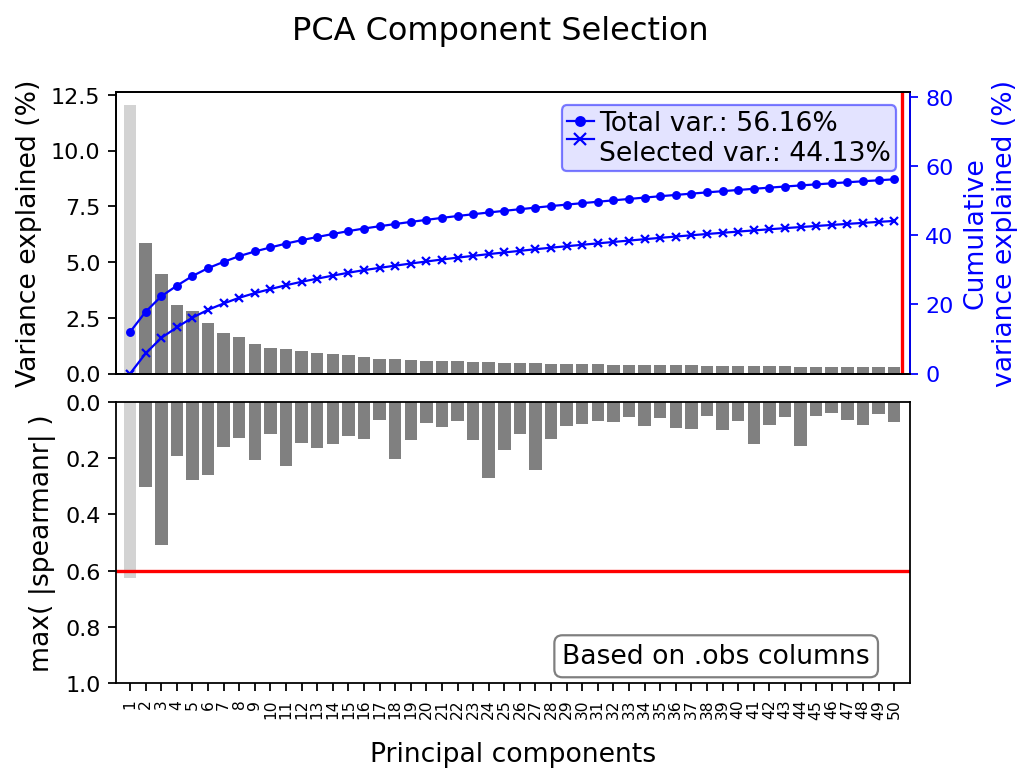

In [21]:
selected_pcs = tools.dim_reduction.propose_pcs(
    anndata=adata,
    how=filter_methods,
    corr_thresh=corr_thresh,
    perc_thresh=perc_thresh,
    corr_kwargs={'method': 'spearmanr', 'which': basis, 'ignore': ignore_cols}
)

# Plot and select number of PCs
_ = pl.embedding.plot_pca_variance(
    adata,
    selected=selected_pcs,
    save='PCA_variance_proposed_selection.pdf',
    n_pcs=50,
    n_thresh=max(selected_pcs),
    corr_plot='spearmanr',
    corr_thresh=corr_thresh,
    corr_on=basis,
    ignore=ignore_cols
)

In [22]:
f"Proposed principal components: {selected_pcs}"

'Proposed principal components: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]'

Create a final PC-selection by changing the blue cell below:
- Either copy and adjust the proposed list from directly above
- create a custom list of PCs
- or accept the proposed list by not changing the cell below.

**Note: the selection will only be applied when `subset_pcs = True`.**

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [23]:
final_pc_selection = selected_pcs

___

[INFO] Saving figure to ../figures/03_batch_correction/PCA_variance_final_selection.pdf


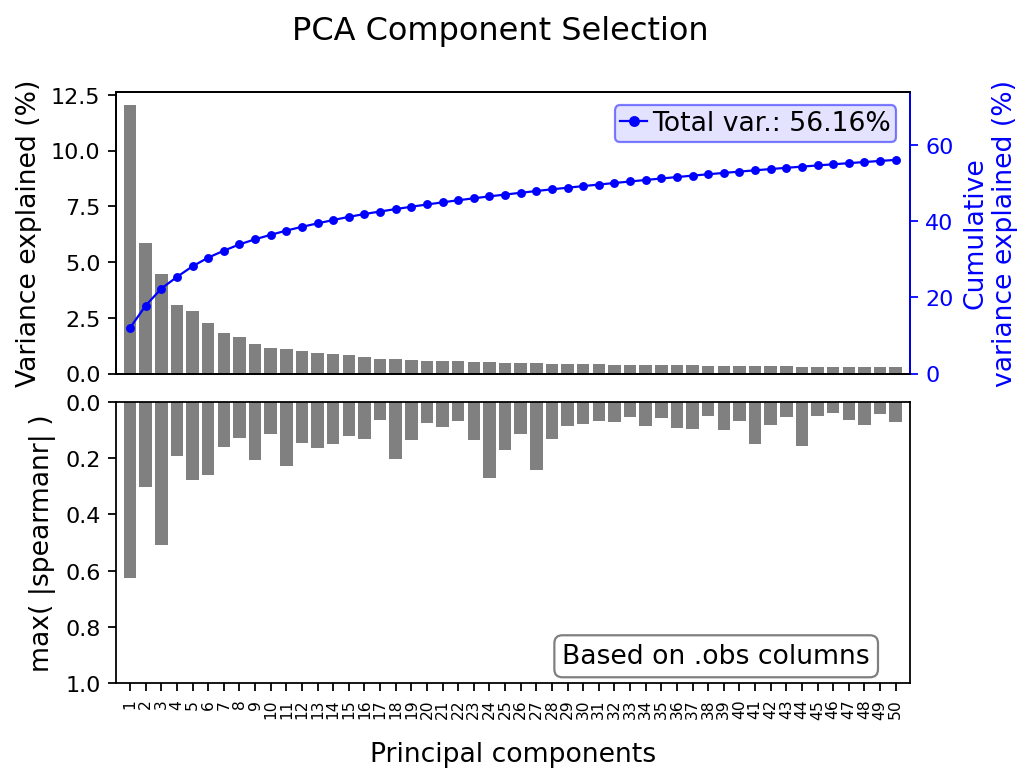

In [24]:
_ = pl.embedding.plot_pca_variance(
    adata, 
    selected=final_pc_selection if subset_pcs else None,
    save='PCA_variance_final_selection.pdf',
    n_pcs=50,
    n_thresh=max(selected_pcs) if subset_pcs else None,
    corr_plot='spearmanr',
    corr_thresh=corr_thresh if subset_pcs else None,
    corr_on=basis,
    ignore=ignore_cols,
    report="03_pca_variance_subset.png"
)

In [25]:
# Subset the number of pcs if chosen in the parameters
if subset_pcs:
    tools.dim_reduction.subset_PCA(adata, select=final_pc_selection, report=True)

------------

### 9.3 - Calculate neighbors
<hr style="border:1px solid black"> </hr>
This step constructs a graph connecting the cells with their k-nearest-neighbors based on the selected dimension reduction components. This graph represents the structure of the data and thus is used to detect clusters visualized in the UMAP in later steps.

#### 9.3.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| `n_neighbors` | Set the number of neighbors | Default 15 |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [26]:
n_neighbors = 20

In [27]:
sc.pp.neighbors(adata, n_neighbors=n_neighbors)

------------

## 10 - Batch correction
<hr style="border:1px solid black"> </hr>

Batch effects are variances in the data that are not intended by the experimental design (e.g. technical variance). They can be introduced through various sources. For example, sequencing samples at different timepoints may introduce batch effects. As batch effects could interfere with downstream analysis they are typically removed. However, it can be challenging to identify and correct for batch effects as this is highly dependent on the experimental setup of the dataset.

**DOI: [10.1038/nrg2825](https://doi.org/10.1038/nrg2825)**

There are several batch correction methods available, which may perform differently depending on the data set. Therefore, an overview is provided to compare batch correction methods and select the best performing one. To help in the decision making process, several metrics are shown that can be selected below and a score (LISI) is provided that explains whether the batches are well mixed after applying the correction.

### 10.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| perform_batch_correction | Whether or not you want to do batch correction | `True` or `False` |
| batch_methods | A list of methods for batch correction | `bbknn`, `mnn`, `harmony`, `scanorama`, `combat` or list more than one method |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [28]:
perform_batch_correction = True
batch_methods = ["bbknn", "mnn", "harmony", "scanorama", "combat"]

In [29]:
if perform_batch_correction:
    # use the options set prior to recompute PCA/ neighbor graph if necessary
    shared_kwargs = {"highly_variable": True,
                     "dim_red_kwargs": {"method_kwargs": {"svd_solver": "arpack", "n_comps": n_pcs},
                                        "subset": final_pc_selection if subset_pcs else None,
                                        "neighbor_kwargs": {"n_neighbors": n_neighbors}}}
    method_kwargs = {meth: shared_kwargs.copy() for meth in batch_methods}
    
    batch_corrections = tools.norm_correct.wrap_corrections(
        adata, 
        batch_key=batch_column,
        methods=batch_methods,
        method_kwargs=method_kwargs
    )
else:
    batch_corrections = {"uncorrected": adata}

[INFO] Running batch correction with 'bbknn'...
[INFO] Running batch correction with 'mnn'...


/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Computing PCA
[INFO] Running batch correction with 'harmony'...
[INFO] Running batch correction with 'scanorama'...
[[0.         0.98452611]
 [0.         0.        ]]
Processing datasets rep_1 <=> rep_2


/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/scanpy/external/pp/_scanorama_integrate.py:148: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[adjusted_basis] = np.concatenate(integrated)


[INFO] Running batch correction with 'combat'...


/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


[INFO] Computing PCA
[INFO] Finished batch correction(s)!


------------

### 10.2 - Plot overview of batch corrections

In [30]:
# Run standard umap for all adatas
tools.embedding.wrap_umap(batch_corrections.values())

Computing UMAPs :   0%|          | 0/6 [00:00<?, ?it/s]

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/sctoolbox/tools/embedding.py:52: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm["X_umap"] = adata_return.obsm["X_umap"]


In [31]:
default_embed_color = [k for k in adata.uns["sctoolbox"]["report"]["qc"]["obs"]["threshold"].keys() if k not in ["before", "after"]] + ["phase", batch_column]
default_embed_color

['log1p_total_counts',
 'n_genes',
 'pct_counts_is_mito',
 'pct_counts_is_ribo',
 'phase',
 'batch']

#### 10.2.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| embed_color | Metrics shown in the following PCA and UMAP | only `batch_column`, a list of columns in `obs` or `var`, or leave it empty to use `default_embed_color` (see above) for relevant metrics |
| do_clustering | Whether or not preliminary clustering should be performed | `True` or `False`

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [32]:
embed_color = [batch_column]

do_clustering = True

___

In [33]:
if do_clustering:
    for adata_tmp in batch_corrections.values():
        sc.tl.leiden(adata_tmp, flavor="igraph", n_iterations=2)
    del adata_tmp
    
    (embed_color if embed_color else default_embed_color).append("leiden")

**LISI score:**  
To determine the strength of a batch effect the Local Inverse Simpson's Index (LISI) can be used by measuring the heterogeneity within a local group. Comparing the LISI score between uncorrected data and the batch correction methods can help in deciding which method performed best.  
The LISI score (stored in `adata.obs`) indicates the effective number of different categories represented in the local neighborhood of each cell. If the cells are well-mixed, then we expect the LISI score to be closer to `n` for a dataset with `n` batches.

**DOI: [10.1038/s41592-019-0619-0](https://doi.org/10.1038/s41592-019-0619-0)**

**The higher the LISI score is, the better the batch correction method worked to normalize the batch effect and mix the cells from different batches.**


In [34]:
# Calculate LISI scores for batch
tools.norm_correct.wrap_batch_evaluation(batch_corrections, batch_key=batch_column, inplace=True, threads=settings.threads)

Calculating LISI scores:   0%|          | 0/12 [00:00<?, ?it/s]

[INFO] Saving figure to ../figures/03_batch_correction/batch_correction_overview.pdf


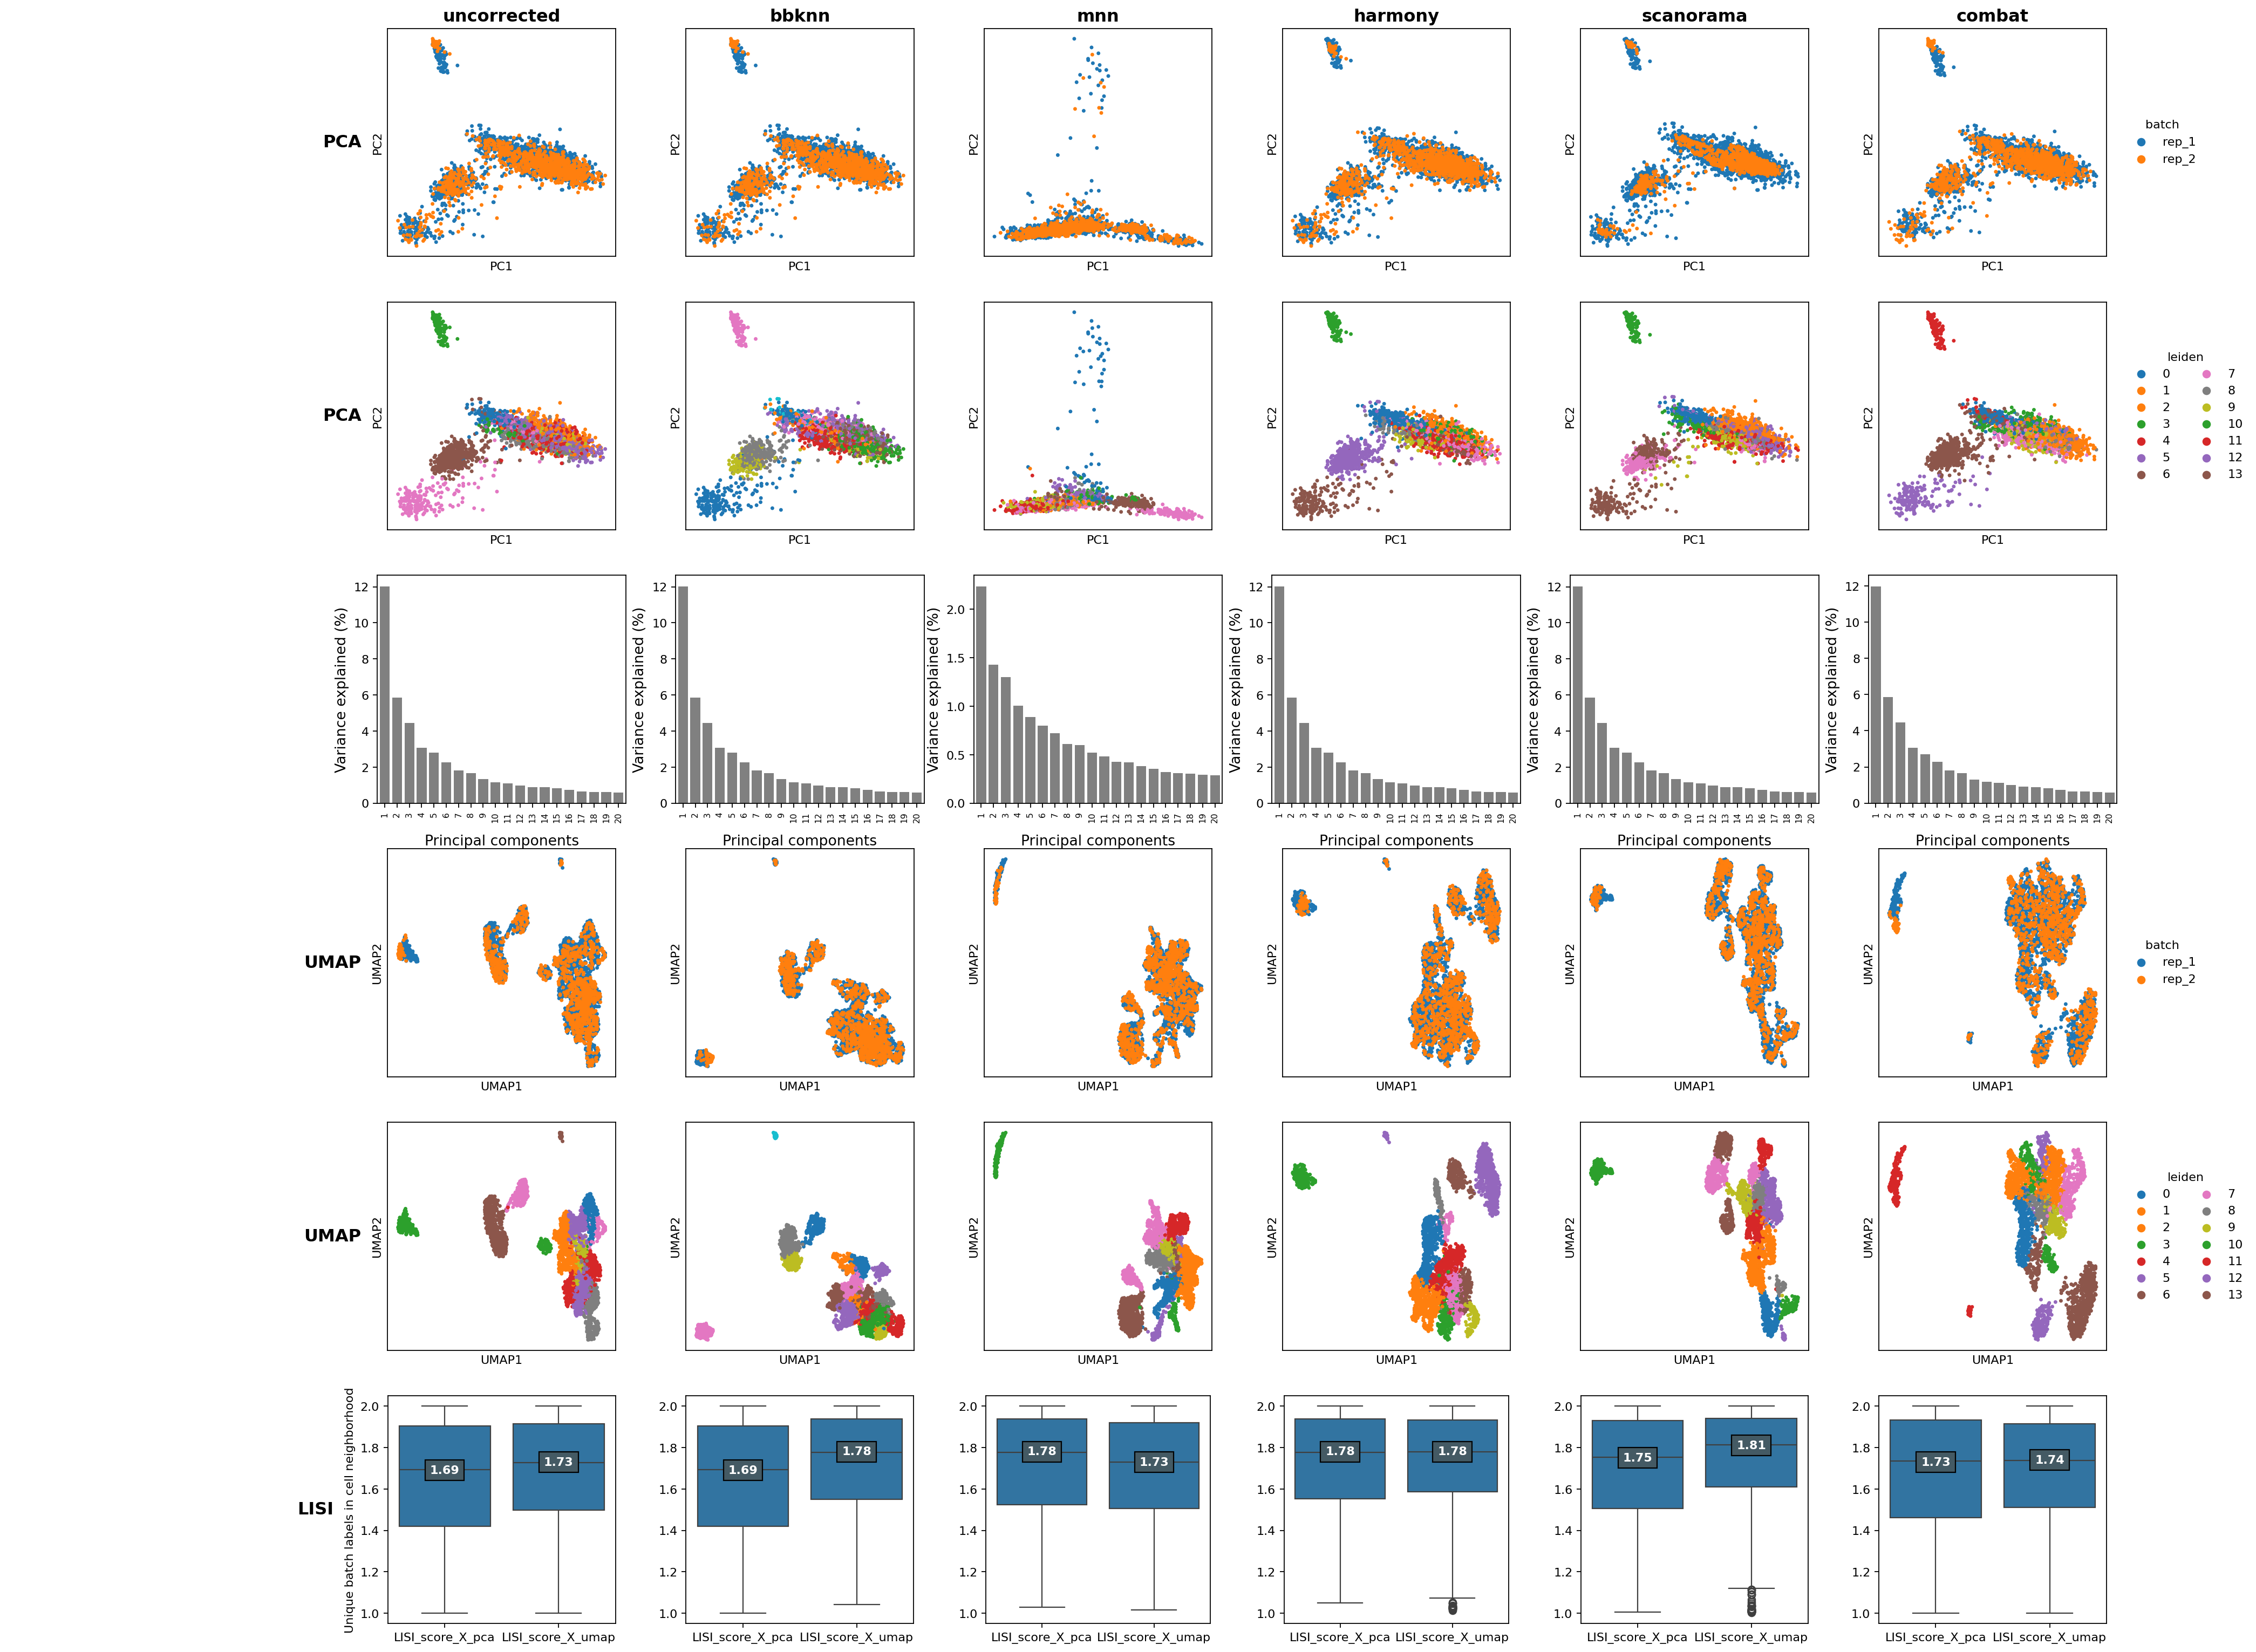

In [35]:
# Plot the overview of batch correction methods
_ = pl.embedding.anndata_overview(
    batch_corrections,
    color_by=embed_color if embed_color else default_embed_color, 
    output="batch_correction_overview.pdf",
    report="04_batchcorrections_overview.png"
)

------------

Choose a batch correction method object to proceed:

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [36]:
selected = "scanorama"

___

In [37]:
if not perform_batch_correction and selected != "uncorrected":
    import warnings
    warnings.warn(f"Selected batch correction '{selected}' but batch correction is disabled. Falling back to 'uncorrected'.")
    
    selected = "uncorrected"
elif selected not in batch_corrections:
    raise KeyError(f"'{selected}' is not a key in batch_corrections. Choose one of: {list(batch_corrections.keys())}")

In [38]:
adata_cor = batch_corrections[selected]
with open(Path(settings.report_dir) / '04_batch_selection.md', 'w') as f: f.write(f"Selected **{selected}** batch correction method.")
utils.io.update_yaml({"batch": selected, "neighbor_count": adata_cor.uns["neighbors"]["params"]["n_neighbors"]}, yml="method.yml", path_prefix="report")

-------------

## 11 - Saving adata for the next notebook

In [39]:
adata_cor

AnnData object with n_obs × n_vars = 3102 × 19031
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap'
    var: 'gene_id', 'is_mito', 'is_ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'sctoolbox', 'log1p', 'pca', 'hvg', 'phase_colors', 'batch_colors', 'neighbors', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'norm'
    obsp: 'distances', 'connectivities'

In [40]:
#Saving the data
adata_output = "anndata_3.h5ad"
utils.adata.save_h5ad(adata_cor, adata_output)

[INFO] The adata object was saved to: ../adatas/anndata_3.h5ad


In [41]:
settings.close_logfile()